In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clusters = pd.read_csv('../data/cluster_outputs/cluster_summary.csv')

In [3]:
clusters

,cluster_id,cluster_size,cluster_percentage,mean_n_clicks_observed,mean_n_unique_pages,mean_n_unique_models,mean_n_unique_categories,mean_n_unique_colours,mean_price_mean,mean_price_min,...,mean_mean_model_frequency,mean_max_model_frequency,mean_min_model_frequency,mean_last_page,mean_last_location,mean_first_model_frequency,mean_last_model_frequency,mean_last_category_frequency,mean_last_colour_frequency,mean_category_transition_count
0,0,2613,10.875718,3.754688,1.770379,3.461921,1.436280,2.693456,43.896679,36.159587,...,0.005622,0.007581,0.004152,1.907769,3.186759,0.006000,0.005631,0.236542,0.086851,0.506697
1,1,3306,13.760093,20.395947,3.874168,17.826679,3.088929,7.487901,42.601867,25.748336,...,0.006518,0.016308,0.001741,3.058076,2.770115,0.010358,0.004738,0.244823,0.095419,3.040835
2,2,2475,10.301340,3.762424,1.853333,3.456162,1.324040,2.481616,36.780075,32.098990,...,0.006065,0.008718,0.004267,2.216162,3.294141,0.007188,0.005559,0.236707,0.114623,0.384646
3,3,2030,8.449180,2.008867,1.126601,1.859606,1.237931,1.593103,37.098036,34.951232,...,0.012938,0.014725,0.011118,1.111330,2.936453,0.013657,0.012306,0.290986,0.132251,0.282759
4,4,3090,12.861067,4.967314,1.443689,4.324919,1.382524,2.420712,52.426751,39.899029,...,0.010681,0.014470,0.007051,1.411650,3.062783,0.011918,0.009704,0.286999,0.146969,0.476375
5,5,5104,21.243653,8.594044,2.161834,7.909875,2.756074,4.986089,44.192250,29.109326,...,0.008480,0.016215,0.003463,1.483542,3.646944,0.010276,0.007767,0.248931,0.108035,2.163205
6,6,1765,7.346208,1.684986,1.208499,1.538810,1.197734,1.416431,34.185873,32.969405,...,0.005643,0.006272,0.005101,1.714448,3.721246,0.005641,0.005625,0.246696,0.095296,0.218130
7,7,3643,15.162740,3.474334,1.323909,3.179522,1.174856,2.514411,53.904485,46.896788,...,0.010049,0.013408,0.007443,1.396102,3.271754,0.010969,0.009504,0.234482,0.095670,0.198737


In [4]:
clusters.drop(columns=['cluster_id']).describe()

,cluster_size,cluster_percentage,mean_n_clicks_observed,mean_n_unique_pages,mean_n_unique_models,mean_n_unique_categories,mean_n_unique_colours,mean_price_mean,mean_price_min,mean_price_max,...,mean_mean_model_frequency,mean_max_model_frequency,mean_min_model_frequency,mean_last_page,mean_last_location,mean_first_model_frequency,mean_last_model_frequency,mean_last_category_frequency,mean_last_colour_frequency,mean_category_transition_count
count,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,3003.25000,12.500000,6.080326,1.845301,5.444687,1.699796,3.199215,43.135752,34.729087,52.996981,...,0.008249,0.012212,0.005542,1.787385,3.236274,0.009501,0.007604,0.253271,0.109389,0.908923
std,1057.85737,4.402969,6.163983,0.892617,5.368825,0.765101,2.042038,7.183488,6.536998,12.797818,...,0.002743,0.004046,0.002916,0.616669,0.326934,0.002906,0.002682,0.022680,0.020888,1.076745
min,1765.00000,7.346208,1.684986,1.126601,1.538810,1.174856,1.416431,34.185873,25.748336,35.510482,...,0.005622,0.006272,0.001741,1.111330,2.770115,0.005641,0.004738,0.234482,0.086851,0.198737
25%,2363.75000,9.838300,3.107968,1.295056,2.849543,1.227882,2.213810,37.018545,31.351574,41.279268,...,0.005959,0.008434,0.003980,1.407763,3.031201,0.006891,0.005608,0.236666,0.095388,0.266602
50%,2851.50000,11.868393,3.758556,1.607034,3.459041,1.353282,2.498014,43.249273,33.960318,55.842844,...,0.007499,0.013939,0.004684,1.598995,3.229256,0.010317,0.006699,0.245760,0.101852,0.430511
75%,3390.25000,14.110755,5.873996,1.930458,5.221158,1.766229,3.266614,46.250876,37.094447,62.746552,...,0.010207,0.015097,0.007149,1.984867,3.382342,0.011206,0.009554,0.258448,0.119030,0.920824
max,5104.00000,21.243653,20.395947,3.874168,17.826679,3.088929,7.487901,53.904485,46.896788,68.584466,...,0.012938,0.016308,0.011118,3.058076,3.721246,0.013657,0.012306,0.290986,0.146969,3.040835


## Cluster Interpretation Analysis

This notebook provides business-meaningful interpretations of the 10 customer behavior clusters identified through k-means clustering.

In [5]:
import numpy as np

# Data-driven selection of most discriminative features
# Use coefficient of variation (CV) to identify features that vary most across clusters

# Get all numeric feature columns (exclude metadata)
feature_cols = [col for col in clusters.columns 
                if col.startswith('mean_') and clusters[col].dtype in ['float64', 'int64']]

# Calculate coefficient of variation for each feature
cv_scores = {}
for col in feature_cols:
    mean_val = clusters[col].mean()
    std_val = clusters[col].std()
    cv = (std_val / mean_val) if mean_val != 0 else 0
    cv_scores[col] = cv

# Create dataframe and sort by discriminative power
feature_importance = pd.DataFrame({
    'feature': list(cv_scores.keys()),
    'coefficient_of_variation': list(cv_scores.values()),
    'std_dev': [clusters[col].std() for col in cv_scores.keys()],
    'mean': [clusters[col].mean() for col in cv_scores.keys()]
}).sort_values('coefficient_of_variation', ascending=False)

print("Top 15 Most Discriminative Features (by Coefficient of Variation):")
print("=" * 80)
feature_importance.head(15).round(3)

Top 15 Most Discriminative Features (by Coefficient of Variation):


,feature,coefficient_of_variation,std_dev,mean
13,mean_category_share_sale,1.544,0.304,0.197
14,mean_category_share_skirts,1.334,0.315,0.236
12,mean_category_share_blouses,1.229,0.289,0.235
26,mean_category_transition_count,1.185,1.077,0.909
15,mean_category_share_trousers,1.097,0.365,0.332
10,mean_high_price_count_first_n,1.089,3.292,3.024
0,mean_n_clicks_observed,1.014,6.164,6.080
2,mean_n_unique_models,0.986,5.369,5.445
11,mean_category_entropy,0.972,0.496,0.510
4,mean_n_unique_colours,0.638,2.042,3.199


### Data-Driven Feature Selection

Rather than arbitrarily choosing a fixed number of features, we use a **statistical threshold**:
- Select features with CV ≥ 75th percentile (top quartile of discriminative power)
- This ensures we include all highly discriminative features without arbitrary cutoffs
- The number of selected features emerges naturally from the data

In [6]:
# Use statistical threshold to select discriminative features
# Features with CV above the 75th percentile (top quartile)
cv_threshold = feature_importance['coefficient_of_variation'].quantile(0.75)

selected_features = feature_importance[
    feature_importance['coefficient_of_variation'] >= cv_threshold
]

# Save selected features to cluster_outputs
import json

selected_features_export = {
    'selection_criteria': {
        'method': 'coefficient_of_variation',
        'threshold_percentile': 0.75,
        'threshold_value': round(float(cv_threshold), 4),
    },
    'total_features_analyzed': len(feature_importance),
    'features_selected': len(selected_features),
    'features': selected_features[['feature', 'coefficient_of_variation', 'std_dev', 'mean']].round(4).to_dict(orient='records'),
}

with open('../data/cluster_outputs/selected_features.json', 'w') as f:
    json.dump(selected_features_export, f, indent=2)
print(f"Saved {len(selected_features)} selected features to data/cluster_outputs/selected_features.json")

print(f"\nSelection Criteria: CV >= {cv_threshold:.3f} (75th percentile)")
print(f"Total features analyzed: {len(feature_importance)}")
print(f"Features selected: {len(selected_features)}")
print(f"Percentage of features selected: {len(selected_features)/len(feature_importance)*100:.1f}%")

print(f"\nSelected Discriminative Features (CV >= 75th percentile):")
print("=" * 80)
for i, row in selected_features.iterrows():
    print(f"  • {row['feature'].replace('mean_', ''):<40} CV: {row['coefficient_of_variation']:.3f}")

key_metrics = ['cluster_id', 'cluster_size', 'cluster_percentage'] + \
              selected_features['feature'].tolist()

print("\nCluster Summary with Selected Discriminative Metrics:")
clusters[key_metrics].round(2)

Saved 7 selected features to data/cluster_outputs/selected_features.json

Selection Criteria: CV >= 1.000 (75th percentile)
Total features analyzed: 27
Features selected: 7
Percentage of features selected: 25.9%

Selected Discriminative Features (CV >= 75th percentile):
  • category_share_sale                      CV: 1.544
  • category_share_skirts                    CV: 1.334
  • category_share_blouses                   CV: 1.229
  • category_transition_count                CV: 1.185
  • category_share_trousers                  CV: 1.097
  • high_price_count_first_n                 CV: 1.089
  • n_clicks_observed                        CV: 1.014

Cluster Summary with Selected Discriminative Metrics:


,cluster_id,cluster_size,cluster_percentage,mean_category_share_sale,mean_category_share_skirts,mean_category_share_blouses,mean_category_transition_count,mean_category_share_trousers,mean_high_price_count_first_n,mean_n_clicks_observed
0,0,2613,10.88,0.05,0.05,0.85,0.51,0.04,2.35,3.75
1,1,3306,13.76,0.33,0.17,0.26,3.04,0.25,10.41,20.40
2,2,2475,10.30,0.90,0.02,0.04,0.38,0.03,1.99,3.76
3,3,2030,8.45,0.04,0.02,0.03,0.28,0.91,0.16,2.01
4,4,3090,12.86,0.04,0.04,0.03,0.48,0.89,2.37,4.97
5,5,5104,21.24,0.17,0.29,0.23,2.16,0.31,4.44,8.59
6,6,1765,7.35,0.03,0.35,0.41,0.22,0.21,0.05,1.68
7,7,3643,15.16,0.01,0.95,0.02,0.20,0.02,2.43,3.47


### Feature Discriminative Power

The following shows which features best differentiate clusters using the **Coefficient of Variation (CV)**:
- CV = Standard Deviation / Mean
- Higher CV = feature varies more across clusters = more discriminative for interpretation

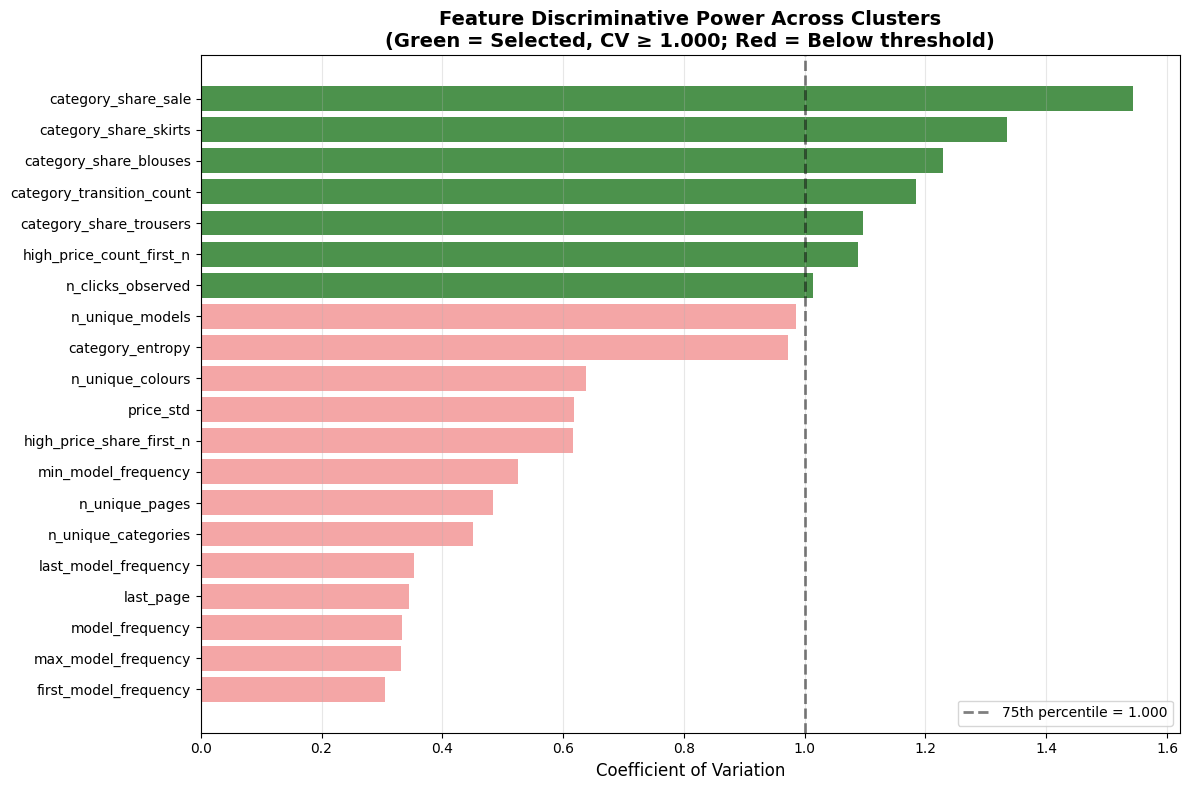

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

# Show top 20 features to give context
n_display = min(20, len(feature_importance))
top_features = feature_importance.head(n_display)

# Color by whether feature meets threshold
colors = ['darkgreen' if cv >= cv_threshold else 'lightcoral' 
          for cv in top_features['coefficient_of_variation']]

ax.barh(range(len(top_features)), top_features['coefficient_of_variation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([feat.replace('mean_', '') for feat in top_features['feature']])
ax.set_xlabel('Coefficient of Variation', fontsize=12)
ax.set_title(f'Feature Discriminative Power Across Clusters\n(Green = Selected, CV ≥ {cv_threshold:.3f}; Red = Below threshold)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=cv_threshold, color='black', linestyle='--', linewidth=2, alpha=0.5, label=f'75th percentile = {cv_threshold:.3f}')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

### Alternative Threshold Options

You can adjust the threshold based on your needs:

In [8]:
# Show impact of different threshold choices
threshold_options = {
    '50th percentile (median)': 0.50,
    '67th percentile (top third)': 0.67,
    '75th percentile (top quartile) [CURRENT]': 0.75,
    '80th percentile (top quintile)': 0.80,
    '90th percentile (top decile)': 0.90
}

threshold_comparison = pd.DataFrame([
    {
        'Threshold': name,
        'CV Value': feature_importance['coefficient_of_variation'].quantile(percentile),
        'Features Selected': (feature_importance['coefficient_of_variation'] >= 
                             feature_importance['coefficient_of_variation'].quantile(percentile)).sum(),
        'Percentage': (feature_importance['coefficient_of_variation'] >= 
                      feature_importance['coefficient_of_variation'].quantile(percentile)).sum() / len(feature_importance) * 100
    }
    for name, percentile in threshold_options.items()
])

print("Impact of Different Threshold Choices:")
print("=" * 80)
threshold_comparison.round(2)

Impact of Different Threshold Choices:


,Threshold,CV Value,Features Selected,Percentage
0,50th percentile (median),0.48,14,51.85
1,67th percentile (top third),0.78,9,33.33
2,75th percentile (top quartile) [CURRENT],1.00,7,25.93
3,80th percentile (top quintile),1.07,6,22.22
4,90th percentile (top decile),1.20,3,11.11


#### Why Threshold-Based Selection?

**Advantages over fixed number selection:**
1. **Adaptive**: Number of features naturally emerges from the data's discriminative structure
2. **Interpretable**: Clear statistical criterion (e.g., "top quartile of variation")
3. **Reproducible**: Same logic applies regardless of how many features exist
4. **Avoids arbitrary cutoffs**: No need to justify "why 10 and not 9 or 11?"
5. **Flexible**: Easy to adjust strictness by changing percentile threshold

The 75th percentile is a reasonable default that typically selects highly discriminative features while avoiding noise, but you can adjust based on your analysis needs (stricter = higher percentile, more lenient = lower percentile).

### Cluster Size Distribution

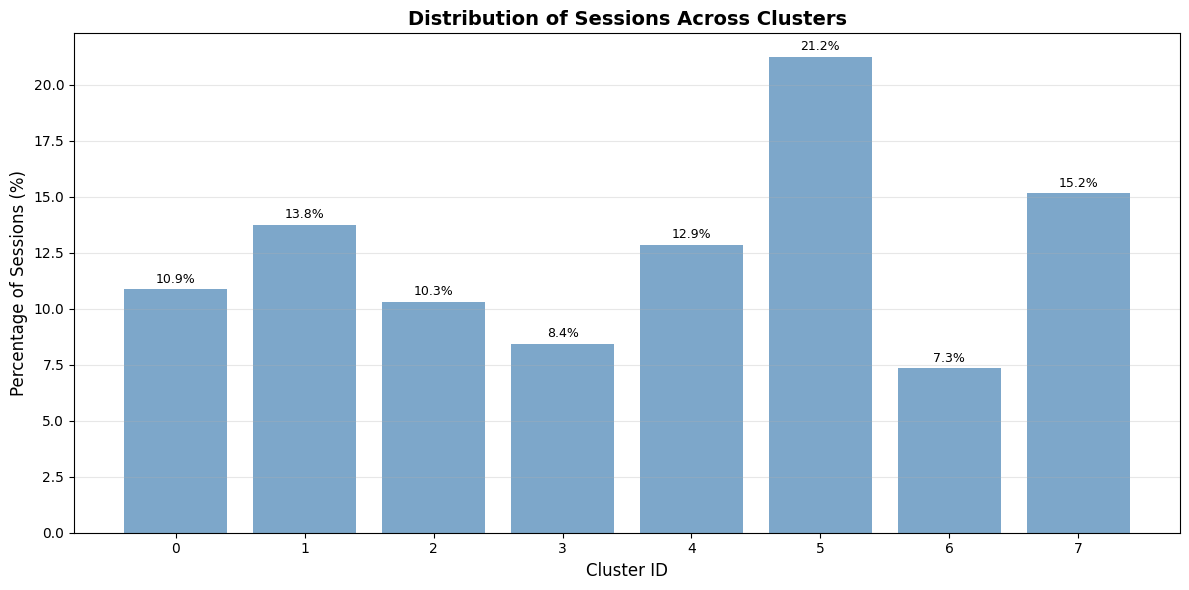

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(clusters['cluster_id'], clusters['cluster_percentage'], color='steelblue', alpha=0.7)
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Percentage of Sessions (%)', fontsize=12)
ax.set_title('Distribution of Sessions Across Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(clusters['cluster_id'])
ax.grid(axis='y', alpha=0.3)

for i, (cid, pct) in enumerate(zip(clusters['cluster_id'], clusters['cluster_percentage'])):
    ax.text(cid, pct + 0.3, f'{pct:.1f}%', ha='center', fontsize=9)
    
plt.tight_layout()
fig.savefig('../data/cluster_outputs/cluster_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Engagement Level Comparison

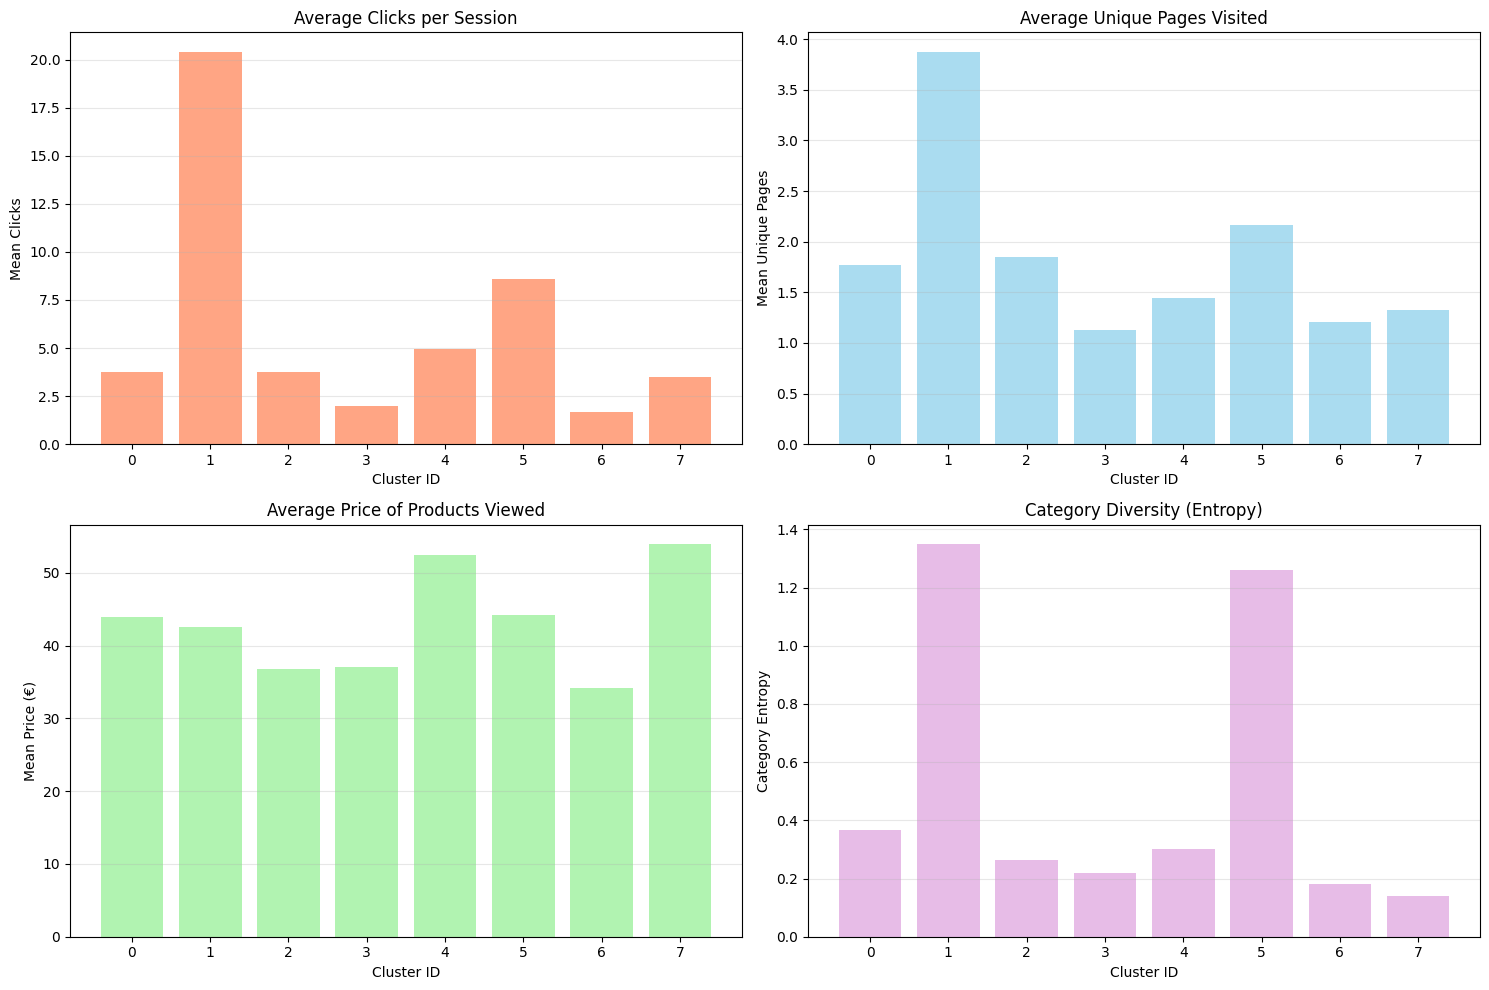

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Clicks
axes[0, 0].bar(clusters['cluster_id'], clusters['mean_n_clicks_observed'], color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Cluster ID')
axes[0, 0].set_ylabel('Mean Clicks')
axes[0, 0].set_title('Average Clicks per Session')
axes[0, 0].grid(axis='y', alpha=0.3)

# Unique pages
axes[0, 1].bar(clusters['cluster_id'], clusters['mean_n_unique_pages'], color='skyblue', alpha=0.7)
axes[0, 1].set_xlabel('Cluster ID')
axes[0, 1].set_ylabel('Mean Unique Pages')
axes[0, 1].set_title('Average Unique Pages Visited')
axes[0, 1].grid(axis='y', alpha=0.3)

# Price mean
axes[1, 0].bar(clusters['cluster_id'], clusters['mean_price_mean'], color='lightgreen', alpha=0.7)
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Mean Price (€)')
axes[1, 0].set_title('Average Price of Products Viewed')
axes[1, 0].grid(axis='y', alpha=0.3)

# Category entropy
axes[1, 1].bar(clusters['cluster_id'], clusters['mean_category_entropy'], color='plum', alpha=0.7)
axes[1, 1].set_xlabel('Cluster ID')
axes[1, 1].set_ylabel('Category Entropy')
axes[1, 1].set_title('Category Diversity (Entropy)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('../data/cluster_outputs/engagement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Category Preferences by Cluster

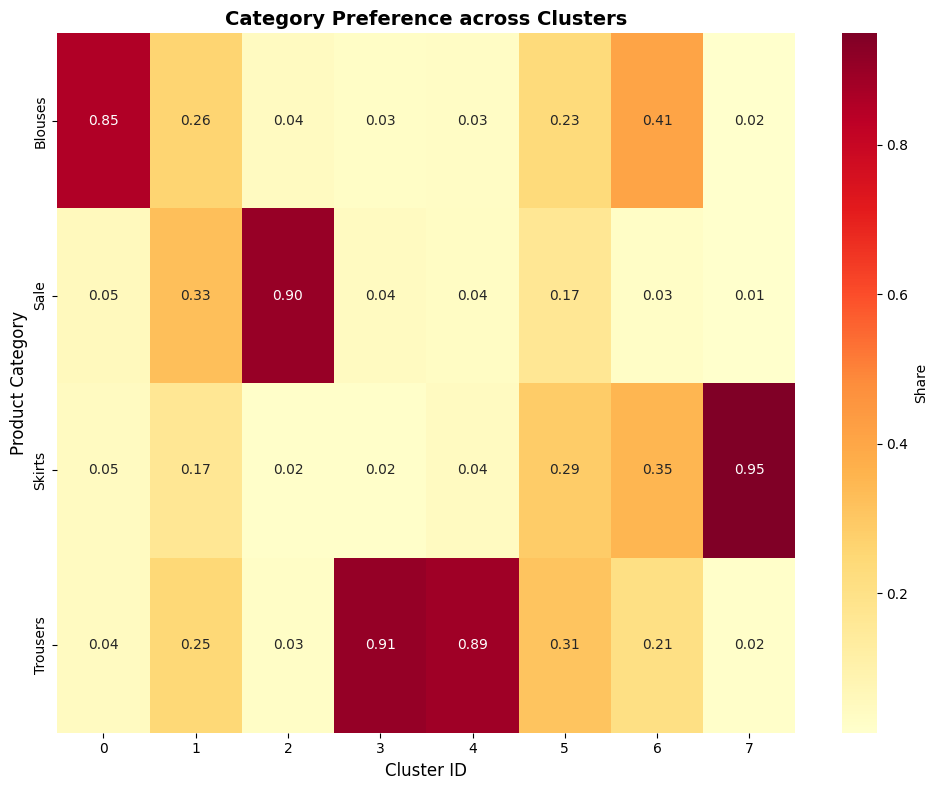

In [11]:
category_cols = [col for col in clusters.columns if 'category_share' in col and col != 'mean_top_category_share']
category_data = clusters[['cluster_id'] + category_cols].set_index('cluster_id')

# Rename columns for better display
category_data.columns = [col.replace('mean_category_share_', '').title() for col in category_data.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(category_data.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Share'}, ax=ax)
ax.set_title('Category Preference across Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Product Category', fontsize=12)
plt.tight_layout()
fig.savefig('../data/cluster_outputs/category_preferences_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Holistic Cluster Interpretations

Each cluster is interpreted by examining the **full feature profile** simultaneously:
- **Engagement depth**: clicks, unique pages, unique models, categories, colours
- **Price behavior**: mean/min/max/std, high-price share
- **Category focus**: entropy, category shares, top-category share, transition count
- **Browsing pattern**: model frequencies (mean/max/min), first vs last model frequency
- **Session trajectory**: last page, last location, last-category/colour frequency

Key principle: a label must be consistent with **all** signals. For example, 1.3 clicks means a bounce — regardless of how high the price of the viewed item is. Likewise, ~1.7-2.0 clicks with shallow depth is treated as a quick-exit signal that often indicates the session was not impressed (disappointment/friction), unless other features strongly contradict that; if revisit intensity is high, interpret it as brief validation before exit rather than random bouncing.

In [12]:
# Holistic cluster interpretation considering ALL features:
#   Engagement depth: clicks, unique pages, unique models, unique categories, unique colours
#   Price behavior:   price mean/min/max/std, high_price_share
#   Category focus:   entropy, category shares, top_category_share, category_transition_count
#   Browsing pattern: model frequencies (mean/max/min), first/last model freq, last page/location
#   Session trajectory: last_category_frequency, last_colour_frequency

interpretations = {
    0: {
        'label': 'Blouse-Focused Evaluators',
        'size': f"{clusters.loc[clusters['cluster_id']==0, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Moderate engagement ({clusters.loc[0, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[0, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[0, 'mean_n_unique_models']:.1f} models, {clusters.loc[0, 'mean_n_unique_colours']:.1f} colours)",
            f"Strong blouse focus ({clusters.loc[0, 'mean_category_share_blouses']:.0%}) with low-to-moderate diversity (entropy {clusters.loc[0, 'mean_category_entropy']:.2f}, top-category share {clusters.loc[0, 'mean_top_category_share']:.2f})",
            f"Mid-price profile (€{clusters.loc[0, 'mean_price_mean']:.0f} avg, €{clusters.loc[0, 'mean_price_min']:.0f}-€{clusters.loc[0, 'mean_price_max']:.0f}, σ={clusters.loc[0, 'mean_price_std']:.1f}) with high early high-price exposure ({clusters.loc[0, 'mean_high_price_share_first_n']:.2f})",
            f"Light comparison pattern (model freq mean/max/min {clusters.loc[0, 'mean_mean_model_frequency']:.3f}/{clusters.loc[0, 'mean_max_model_frequency']:.3f}/{clusters.loc[0, 'mean_min_model_frequency']:.3f}) and limited switching ({clusters.loc[0, 'mean_category_transition_count']:.2f})",
            f"Session endings stay relatively stable (last page {clusters.loc[0, 'mean_last_page']:.2f}, last-category frequency {clusters.loc[0, 'mean_last_category_frequency']:.2f}), which is more evaluative than immediate abandonment",
        ],
        'intent': 'Blouse-oriented shoppers evaluating a shortlist with moderate comparison, not an immediate disappointment pattern.',
    },
    1: {
        'label': 'Deep Cross-Category Researchers',
        'size': f"{clusters.loc[clusters['cluster_id']==1, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Extreme engagement intensity ({clusters.loc[1, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[1, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[1, 'mean_n_unique_models']:.1f} models, {clusters.loc[1, 'mean_n_unique_colours']:.1f} colours) - about {clusters.loc[1, 'mean_n_clicks_observed']/clusters.loc[5, 'mean_n_clicks_observed']:.1f}x the clicks of Cluster 5",
            f"Most diverse category behavior (entropy {clusters.loc[1, 'mean_category_entropy']:.2f}, {clusters.loc[1, 'mean_n_unique_categories']:.1f} categories, transitions {clusters.loc[1, 'mean_category_transition_count']:.2f}, top-category share {clusters.loc[1, 'mean_top_category_share']:.2f})",
            f"Balanced category mix across blouses ({clusters.loc[1, 'mean_category_share_blouses']:.0%}), sale ({clusters.loc[1, 'mean_category_share_sale']:.0%}), skirts ({clusters.loc[1, 'mean_category_share_skirts']:.0%}), and trousers ({clusters.loc[1, 'mean_category_share_trousers']:.0%})",
            f"Wide price exploration (€{clusters.loc[1, 'mean_price_min']:.0f}-€{clusters.loc[1, 'mean_price_max']:.0f}, σ={clusters.loc[1, 'mean_price_std']:.1f}) with mid-range average (€{clusters.loc[1, 'mean_price_mean']:.0f})",
            f"Discovery-heavy model dynamics (first-to-last model frequency {clusters.loc[1, 'mean_first_model_frequency']:.3f} to {clusters.loc[1, 'mean_last_model_frequency']:.3f}) with much deeper browsing than Cluster 5 (last page {clusters.loc[1, 'mean_last_page']:.2f} vs {clusters.loc[5, 'mean_last_page']:.2f})",
        ],
        'intent': 'Exhaustive cross-category researchers with very high deliberation intensity before narrowing, clearly deeper than Cluster 5.',
    },
    2: {
        'label': 'Focused Sale Browsers',
        'size': f"{clusters.loc[clusters['cluster_id']==2, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Moderate engagement ({clusters.loc[2, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[2, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[2, 'mean_n_unique_models']:.1f} models)",
            f"Overwhelming sale concentration ({clusters.loc[2, 'mean_category_share_sale']:.0%}) with low category spread (entropy {clusters.loc[2, 'mean_category_entropy']:.2f}, top-category share {clusters.loc[2, 'mean_top_category_share']:.2f})",
            f"Budget-to-mid price profile (€{clusters.loc[2, 'mean_price_mean']:.0f} avg, €{clusters.loc[2, 'mean_price_min']:.0f}-€{clusters.loc[2, 'mean_price_max']:.0f}, σ={clusters.loc[2, 'mean_price_std']:.1f})",
            f"Controlled browsing and comparison (transitions {clusters.loc[2, 'mean_category_transition_count']:.2f}, model freq mean/max/min {clusters.loc[2, 'mean_mean_model_frequency']:.3f}/{clusters.loc[2, 'mean_max_model_frequency']:.3f}/{clusters.loc[2, 'mean_min_model_frequency']:.3f})",
            f"Sessions go beyond the landing page (last page {clusters.loc[2, 'mean_last_page']:.2f}) while end-state category focus remains consistent (last-category frequency {clusters.loc[2, 'mean_last_category_frequency']:.2f}), suggesting purposeful deal search more than disappointment",
        ],
        'intent': 'Deal-focused shoppers browsing sale inventory with moderate depth and a purposeful, low-friction pattern.',
    },
    3: {
        'label': 'Quick Trouser Validators',
        'size': f"{clusters.loc[clusters['cluster_id']==3, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Low engagement footprint ({clusters.loc[3, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[3, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[3, 'mean_n_unique_models']:.1f} models, {clusters.loc[3, 'mean_n_unique_colours']:.1f} colours) is a quick-exit signal consistent with many sessions not being impressed",
            f"Strong trouser concentration ({clusters.loc[3, 'mean_category_share_trousers']:.0%}) with low diversity (entropy {clusters.loc[3, 'mean_category_entropy']:.2f}, top-category share {clusters.loc[3, 'mean_top_category_share']:.2f})",
            f"Low and tight price range (€{clusters.loc[3, 'mean_price_mean']:.0f} avg, €{clusters.loc[3, 'mean_price_min']:.0f}-€{clusters.loc[3, 'mean_price_max']:.0f}, σ={clusters.loc[3, 'mean_price_std']:.1f}) and low high-price exposure ({clusters.loc[3, 'mean_high_price_share_first_n']:.2f})",
            f"Highest model revisit intensity (model freq mean/max/min {clusters.loc[3, 'mean_mean_model_frequency']:.3f}/{clusters.loc[3, 'mean_max_model_frequency']:.3f}/{clusters.loc[3, 'mean_min_model_frequency']:.3f}; first/last {clusters.loc[3, 'mean_first_model_frequency']:.3f}/{clusters.loc[3, 'mean_last_model_frequency']:.3f})",
            f"Minimal switching and shallow depth (transitions {clusters.loc[3, 'mean_category_transition_count']:.2f}, last page {clusters.loc[3, 'mean_last_page']:.2f}) reinforce fast exits after brief validation",
        ],
        'intent': 'Quick trouser checkers doing brief validation on familiar low-price options; many sessions appear unconvinced and exit quickly.',
    },
    4: {
        'label': 'Premium Trouser Comparers',
        'size': f"{clusters.loc[clusters['cluster_id']==4, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"High engagement within a narrow footprint ({clusters.loc[4, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[4, 'mean_n_unique_models']:.1f} models, {clusters.loc[4, 'mean_n_unique_pages']:.1f} pages)",
            f"Trouser-dominant sessions ({clusters.loc[4, 'mean_category_share_trousers']:.0%}) with low diversity but not single-item behavior (entropy {clusters.loc[4, 'mean_category_entropy']:.2f}, transitions {clusters.loc[4, 'mean_category_transition_count']:.2f})",
            f"Premium price profile (€{clusters.loc[4, 'mean_price_mean']:.0f} avg, €{clusters.loc[4, 'mean_price_min']:.0f}-€{clusters.loc[4, 'mean_price_max']:.0f}, σ={clusters.loc[4, 'mean_price_std']:.1f})",
            f"Active comparison on shortlisted products (model freq mean/max/min {clusters.loc[4, 'mean_mean_model_frequency']:.3f}/{clusters.loc[4, 'mean_max_model_frequency']:.3f}/{clusters.loc[4, 'mean_min_model_frequency']:.3f}; first/last {clusters.loc[4, 'mean_first_model_frequency']:.3f}/{clusters.loc[4, 'mean_last_model_frequency']:.3f})",
            f"Stable session end in the same category (last-category frequency {clusters.loc[4, 'mean_last_category_frequency']:.2f}, last-colour frequency {clusters.loc[4, 'mean_last_colour_frequency']:.2f})",
        ],
        'intent': 'High-consideration shoppers comparing premium trouser options with focused within-category decision behavior.',
    },
    5: {
        'label': 'Engaged Multi-Category Explorers',
        'size': f"{clusters.loc[clusters['cluster_id']==5, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Largest segment ({clusters.loc[5, 'cluster_percentage']:.1f}% of sessions) with strong but not extreme engagement ({clusters.loc[5, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[5, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[5, 'mean_n_unique_models']:.1f} models) - materially below Cluster 1",
            f"High cross-category breadth (entropy {clusters.loc[5, 'mean_category_entropy']:.2f}, transitions {clusters.loc[5, 'mean_category_transition_count']:.2f}, top-category share {clusters.loc[5, 'mean_top_category_share']:.2f}) with balanced blouse/sale/skirts/trousers shares",
            f"Broad price exploration (€{clusters.loc[5, 'mean_price_min']:.0f}-€{clusters.loc[5, 'mean_price_max']:.0f}, σ={clusters.loc[5, 'mean_price_std']:.1f}, avg €{clusters.loc[5, 'mean_price_mean']:.0f})",
            f"Mixed model behavior (high max frequency {clusters.loc[5, 'mean_max_model_frequency']:.3f} with low minimum {clusters.loc[5, 'mean_min_model_frequency']:.3f}) indicating both discovery and selective revisits",
            f"Sessions are exploratory but lighter than Cluster 1 across intensity signals (clicks {clusters.loc[5, 'mean_n_clicks_observed']:.1f} vs {clusters.loc[1, 'mean_n_clicks_observed']:.1f}, transitions {clusters.loc[5, 'mean_category_transition_count']:.2f} vs {clusters.loc[1, 'mean_category_transition_count']:.2f}, last page {clusters.loc[5, 'mean_last_page']:.2f} vs {clusters.loc[1, 'mean_last_page']:.2f})",
        ],
        'intent': 'Broad multi-category explorers with moderate-to-high engagement, but not the exhaustive deep-research behavior seen in Cluster 1.',
    },
    6: {
        'label': 'Budget Quick Viewers',
        'size': f"{clusters.loc[clusters['cluster_id']==6, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Lowest engagement profile ({clusters.loc[6, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[6, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[6, 'mean_n_unique_models']:.1f} models, {clusters.loc[6, 'mean_n_unique_colours']:.1f} colours) suggests many sessions exit before finding something compelling",
            f"Low diversity with strong session-level concentration (entropy {clusters.loc[6, 'mean_category_entropy']:.2f}, top-category share {clusters.loc[6, 'mean_top_category_share']:.2f}) despite mixed aggregate shares across blouses, skirts, and trousers",
            f"Most budget-constrained pricing (€{clusters.loc[6, 'mean_price_mean']:.0f} avg, €{clusters.loc[6, 'mean_price_min']:.0f}-€{clusters.loc[6, 'mean_price_max']:.0f}, σ={clusters.loc[6, 'mean_price_std']:.2f}) with near-zero high-price exposure ({clusters.loc[6, 'mean_high_price_share_first_n']:.3f})",
            f"Very flat and low model frequencies (mean/max/min {clusters.loc[6, 'mean_mean_model_frequency']:.3f}/{clusters.loc[6, 'mean_max_model_frequency']:.3f}/{clusters.loc[6, 'mean_min_model_frequency']:.3f}; first and last both {clusters.loc[6, 'mean_first_model_frequency']:.3f})",
            f"Quick exits with little switching (transitions {clusters.loc[6, 'mean_category_transition_count']:.2f}, last page {clusters.loc[6, 'mean_last_page']:.2f}) are consistent with low excitement/disappointment behavior",
        ],
        'intent': 'Low-intent budget visitors with strong quick-exit disappointment signals (not impressed, minimal exploration, rapid leave).',
    },
    7: {
        'label': 'Premium Skirt-Focused Shoppers',
        'size': f"{clusters.loc[clusters['cluster_id']==7, 'cluster_percentage'].values[0]:.1f}%",
        'key_characteristics': [
            f"Moderate engagement ({clusters.loc[7, 'mean_n_clicks_observed']:.1f} clicks, {clusters.loc[7, 'mean_n_unique_pages']:.1f} pages, {clusters.loc[7, 'mean_n_unique_models']:.1f} models)",
            f"Strongest category concentration in skirts ({clusters.loc[7, 'mean_category_share_skirts']:.0%}) with the lowest diversity and switching (entropy {clusters.loc[7, 'mean_category_entropy']:.2f}, transitions {clusters.loc[7, 'mean_category_transition_count']:.2f})",
            f"Highest price-tier exposure (€{clusters.loc[7, 'mean_price_mean']:.0f} avg, €{clusters.loc[7, 'mean_price_min']:.0f}-€{clusters.loc[7, 'mean_price_max']:.0f}) and highest early high-price share ({clusters.loc[7, 'mean_high_price_share_first_n']:.2f})",
            f"Structured comparison within one category (model freq mean/max/min {clusters.loc[7, 'mean_mean_model_frequency']:.3f}/{clusters.loc[7, 'mean_max_model_frequency']:.3f}/{clusters.loc[7, 'mean_min_model_frequency']:.3f}; first/last {clusters.loc[7, 'mean_first_model_frequency']:.3f}/{clusters.loc[7, 'mean_last_model_frequency']:.3f})",
            f"Consistent session endings without cross-category drift (last page {clusters.loc[7, 'mean_last_page']:.2f}, last-category frequency {clusters.loc[7, 'mean_last_category_frequency']:.2f}), indicating targeted evaluation rather than broad exploration",
        ],
        'intent': 'Premium skirt-focused shoppers making targeted within-category comparisons with limited cross-category exploration.',
    },
}

# Create a summary dataframe
interpretation_df = pd.DataFrame([
    {
        'Cluster': k,
        'Label': v['label'],
        'Size': v['size'],
        'Primary Intent': v['intent']
    }
    for k, v in interpretations.items()
])

interpretation_df


,Cluster,Label,Size,Primary Intent
0,0,Blouse-Focused Evaluators,10.9%,Blouse-oriented shoppers evaluating a shortlis...
1,1,Deep Cross-Category Researchers,13.8%,Exhaustive cross-category researchers with ver...
2,2,Focused Sale Browsers,10.3%,Deal-focused shoppers browsing sale inventory ...
3,3,Quick Trouser Validators,8.4%,Quick trouser checkers doing brief validation ...
4,4,Premium Trouser Comparers,12.9%,High-consideration shoppers comparing premium ...
5,5,Engaged Multi-Category Explorers,21.2%,Broad multi-category explorers with moderate-t...
6,6,Budget Quick Viewers,7.3%,Low-intent budget visitors with strong quick-e...
7,7,Premium Skirt-Focused Shoppers,15.2%,Premium skirt-focused shoppers making targeted...


In [13]:
for k, v in interpretations.items():
    print(f"Cluster {k}")
    print(f"{v['label']} - size {v['size']}\n")
    print(f"Key characteristics:\n{v['key_characteristics']}")
    print(f"Business context: {v['intent']}\n")

Cluster 0
Blouse-Focused Evaluators - size 10.9%

Key characteristics:
['Moderate engagement (3.8 clicks, 1.8 pages, 3.5 models, 2.7 colours)', 'Strong blouse focus (85%) with low-to-moderate diversity (entropy 0.37, top-category share 0.86)', 'Mid-price profile (€44 avg, €36-€51, σ=7.1) with high early high-price exposure (0.73)', 'Light comparison pattern (model freq mean/max/min 0.006/0.008/0.004) and limited switching (0.51)', 'Session endings stay relatively stable (last page 1.91, last-category frequency 0.24), which is more evaluative than immediate abandonment']
Business context: Blouse-oriented shoppers evaluating a shortlist with moderate comparison, not an immediate disappointment pattern.

Cluster 1
Deep Cross-Category Researchers - size 13.8%

Key characteristics:
['Extreme engagement intensity (20.4 clicks, 3.9 pages, 17.8 models, 7.5 colours) - about 2.4x the clicks of Cluster 5', 'Most diverse category behavior (entropy 1.35, 3.1 categories, transitions 3.04, top-catego

### Cluster Positioning Map: Engagement vs Price

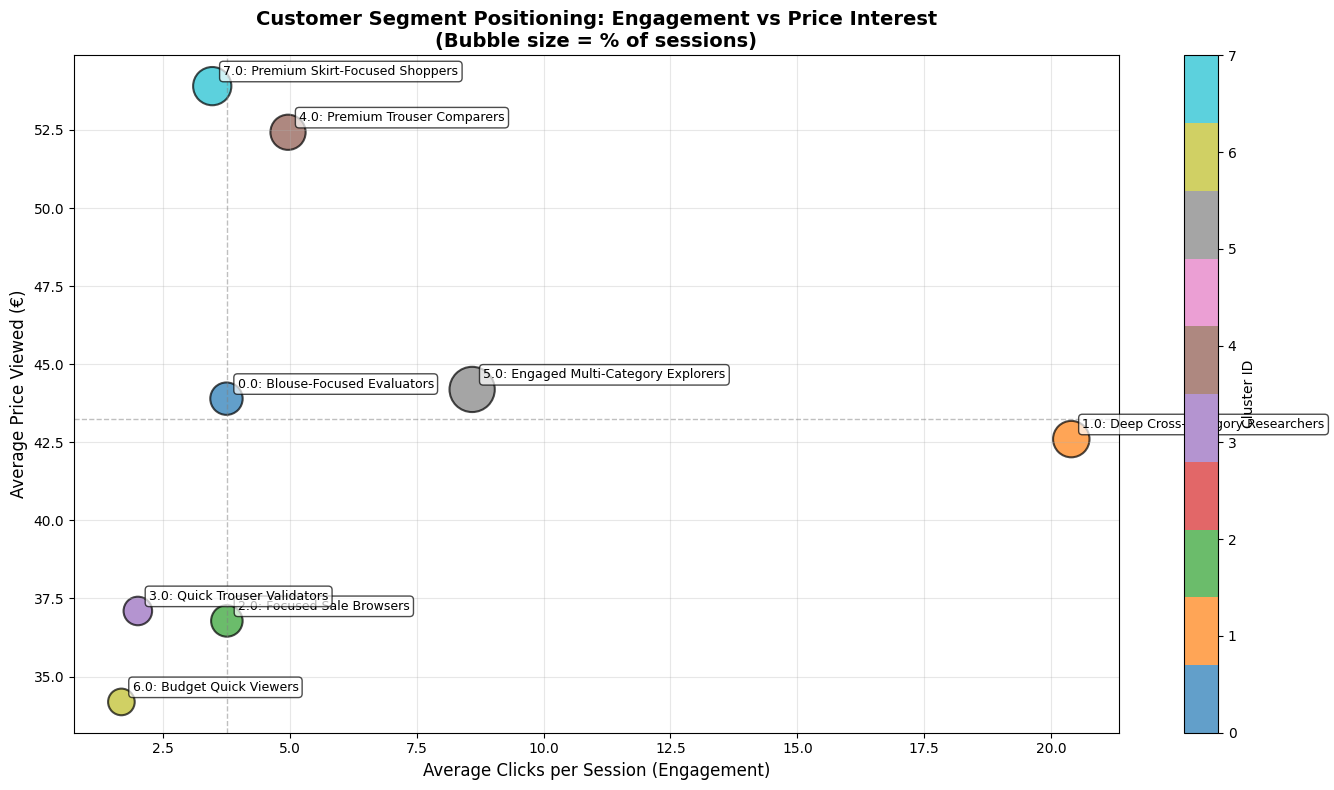

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot
scatter = ax.scatter(
    clusters['mean_n_clicks_observed'],
    clusters['mean_price_mean'],
    s=clusters['cluster_percentage'] * 50,  # Size by percentage
    c=clusters['cluster_id'],
    cmap='tab10',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

# Add cluster labels
for idx, row in clusters.iterrows():
    label = interpretations[row['cluster_id']]['label']
    ax.annotate(
        f"{row['cluster_id']}: {label}",
        (row['mean_n_clicks_observed'], row['mean_price_mean']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

ax.set_xlabel('Average Clicks per Session (Engagement)', fontsize=12)
ax.set_ylabel('Average Price Viewed (€)', fontsize=12)
ax.set_title('Customer Segment Positioning: Engagement vs Price Interest\n(Bubble size = % of sessions)', 
          fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
fig.colorbar(scatter, label='Cluster ID')

# Add quadrant lines
ax.axhline(y=clusters['mean_price_mean'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=clusters['mean_n_clicks_observed'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
fig.savefig('../data/cluster_outputs/cluster_positioning_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics by Segment Type

In [15]:
# Categorize clusters by engagement and price
clusters['engagement_level'] = pd.cut(
    clusters['mean_n_clicks_observed'], 
    bins=[0, 2, 3.5, 5], 
    labels=['Low', 'Medium', 'High']
)

clusters['price_tier'] = pd.cut(
    clusters['mean_price_mean'],
    bins=[0, 40, 50, 100],
    labels=['Budget', 'Mid-Range', 'Premium']
)

# Summary by segment type
segment_summary = clusters.groupby(['engagement_level', 'price_tier'], observed=True).agg({
    'cluster_id': 'count',
    'cluster_percentage': 'sum',
    'mean_n_clicks_observed': 'mean',
    'mean_price_mean': 'mean'
}).round(2)

segment_summary.columns = ['# Clusters', 'Total % Sessions', 'Avg Clicks', 'Avg Price']
segment_summary

# Clusters  Total % Sessions  Avg Clicks  \
engagement_level price_tier                                             
Low              Budget               1              7.35        1.68   
Medium           Budget               1              8.45        2.01   
                 Premium              1             15.16        3.47   
High             Budget               1             10.30        3.76   
                 Mid-Range            1             10.88        3.75   
                 Premium              1             12.86        4.97   

                             Avg Price  
engagement_level price_tier             
Low              Budget          34.19  
Medium           Budget          37.10  
                 Premium         53.90  
High             Budget          36.78  
                 Mid-Range       43.90  
                 Premium         52.43

## Export Cluster Interpretations

In [16]:
# Export interpretation summary
interpretation_export = pd.DataFrame([
    {
        'cluster_id': k,
        'cluster_label': v['label'],
        'cluster_size_pct': v['size'],
        'business_intent': v['intent']
    }
    for k, v in interpretations.items()
])

output_path = '../data/cluster_outputs/cluster_interpretations.csv'
interpretation_export.to_csv(output_path, index=False)
print(f"Cluster interpretations exported to: {output_path}")

interpretation_export

Cluster interpretations exported to: ../data/cluster_outputs/cluster_interpretations.csv


,cluster_id,cluster_label,cluster_size_pct,business_intent
0,0,Blouse-Focused Evaluators,10.9%,Blouse-oriented shoppers evaluating a shortlis...
1,1,Deep Cross-Category Researchers,13.8%,Exhaustive cross-category researchers with ver...
2,2,Focused Sale Browsers,10.3%,Deal-focused shoppers browsing sale inventory ...
3,3,Quick Trouser Validators,8.4%,Quick trouser checkers doing brief validation ...
4,4,Premium Trouser Comparers,12.9%,High-consideration shoppers comparing premium ...
5,5,Engaged Multi-Category Explorers,21.2%,Broad multi-category explorers with moderate-t...
6,6,Budget Quick Viewers,7.3%,Low-intent budget visitors with strong quick-e...
7,7,Premium Skirt-Focused Shoppers,15.2%,Premium skirt-focused shoppers making targeted...
